In [4]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
orange_path = '/kaggle/input/datasets/abhinav6744/orange-disease-data/orange/Citrus Leaf Disease Image/'

for cls in os.listdir(orange_path):
    cls_path = os.path.join(orange_path, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls} → {count} images")

  Black spot → 169 images
  Canker → 163 images
  Melanose → 13 images
  Healthy → 58 images
  Greening → 204 images


In [6]:
source = '/kaggle/input/datasets/abhinav6744/orange-disease-data/orange/Citrus Leaf Disease Image/'
dest   = '/kaggle/working/orange_dataset/'

needed = ['Black spot', 'Canker', 'Healthy', 'Greening']

for cls in needed:
    src_path = os.path.join(source, cls)
    dst_path = os.path.join(dest, cls)
    if not os.path.exists(dst_path):
        shutil.copytree(src_path, dst_path)
    print(f"Copied {cls} → {len(os.listdir(dst_path))} images")

Copied Black spot → 169 images
Copied Canker → 163 images
Copied Healthy → 58 images
Copied Greening → 204 images


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dest,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    dest,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_generator.class_indices)
NUM_CLASSES = len(train_generator.class_indices)
print("Total classes:", NUM_CLASSES)

Found 478 images belonging to 4 classes.
Found 116 images belonging to 4 classes.
Classes: {'Black spot': 0, 'Canker': 1, 'Greening': 2, 'Healthy': 3}
Total classes: 4


In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774508956.485495      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774508956.491525      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1774508985.163791     154 service.cc:152] XLA service 0x7a3250003e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774508985.163831     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774508985.163836     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774508985.553159     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/15 ━━━━━━━━━━━━━━━━━━━━ 1:20 6s/step - accuracy: 0.1333 - loss: 1.4178

I0000 00:00:1774508989.275437     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 581ms/step - accuracy: 0.2926 - loss: 1.5623 - val_accuracy: 0.3966 - val_loss: 1.2354
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.4097 - loss: 1.1931 - val_accuracy: 0.5000 - val_loss: 1.0679
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step - accuracy: 0.4821 - loss: 1.0776 - val_accuracy: 0.5431 - val_loss: 1.1055
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.4617 - loss: 1.0752 - val_accuracy: 0.5431 - val_loss: 0.9559
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.5179 - loss: 0.9195 - val_accuracy: 0.5086 - val_loss: 0.9519
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.6178 - loss: 0.9174 - val_accuracy: 0.5345 - val_loss: 0.8815
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.5954 - loss: 0.8780 - val_accuracy: 0.5345 - val_loss: 0.8267
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.6142 - loss: 0.8043 - val_accuracy: 0.5948 - val

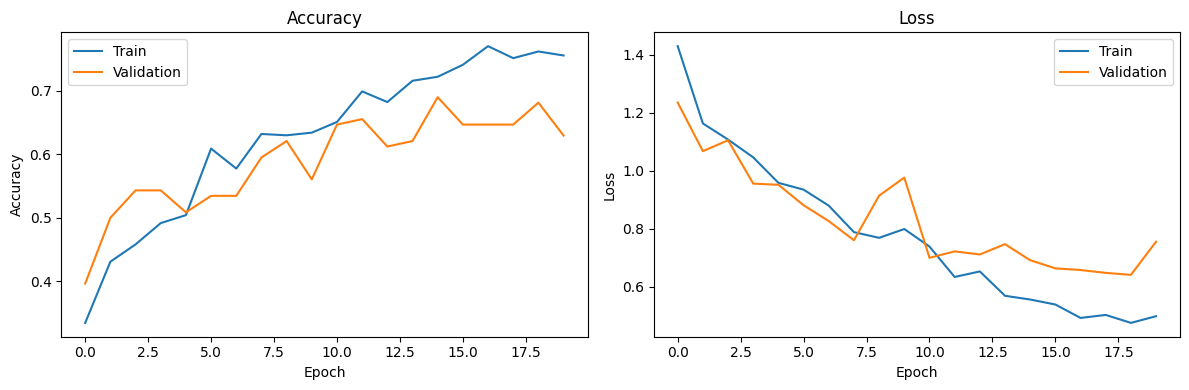

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


In [13]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6967 - loss: 0.6859
Final Validation Accuracy: 68.97%
Final Validation Loss: 0.6919


In [14]:
model.save('/kaggle/working/orange_model.h5')

labels = [label for label, index in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]

with open('/kaggle/working/orange_labels.txt', 'w') as f:
    for label in labels:
        f.write(label + '\n')

print("Model saved!")
print("Labels saved:", labels)

Model saved!
Labels saved: ['Black spot', 'Canker', 'Greening', 'Healthy']
